# Vizualización de la continuación en una rama de $ \sqrt{f(z)} $


Queremos vizualizar la estructura de dos hojas y construir la intuición de monodromía.

sea  $$ f(z) = \prod_{i=1}^{6}{(z-e_i)} $$

Al evaluar $\sqrt{f(z)}$ la rama puede saltar, por lo que no basta con solo evaluar punto a punto. Se debe dar un seguimento continuo del signo de la raíz a lo largo de un camino.

In [84]:
import numpy as np
import matplotlib.pyplot as plt

Creamos una función que genere los paths, dado el radio y el centro en los que quiero los z en coordenadas polares.

In [85]:
#centrado en 0 y radio 1
#z_path = np.exp(1j * puntos)

def z_path(r,c, puntos):
    z =r*np.exp(1j * puntos) + c
    return z


Definimos el polinomio f

In [86]:
def f(z,k,e):
    a = np.prod(z[k]-e)
    return a

Ahora la función que va a garantizar que siga el mismo camino y no salte de rama en rama.

In [87]:
def continue_sqrt_along_path(z,e):
    y_f = []

    f0 = f(z, 0, e)
    y0 = np.sqrt(f0)
    y_f.append(y0)

    for k in range(1, len(z)):
        positivo = np.sqrt(f(z,k,e))
        negativo = (-1)*positivo

        y_anterior = y_f[-1]

        if abs(y_anterior - positivo) < abs(y_anterior - negativo):
            y_k = positivo
        else:
             y_k = negativo

        y_f.append(y_k)

    return np.array(y_f)


    

# Experimentos

### 1. Un circulo que rodea exactamente un punto de ramificación

In [88]:
e=np.array([0,0.2,0.5,0.9,1,2])

In [89]:
#VAMOS A TRABAJAR CON E2

index = 1  
gap_izq = e[index] - e[index-1]
gap_der = e[index+1] - e[index]
radio1 = min(gap_izq, gap_der) / 2 * 0.8 

In [90]:
puntos1 = np.linspace(0, 2*np.pi, 200)
camino1 = z_path(radio1, e[index], puntos1)

y_f = continue_sqrt_along_path(camino1, e)

y01 = y_f[0]
y_final1 = y_f[-1]

print(y01, y_final1)

(0.061512257510190606-0j) (-0.061512257510190606+4.786691045899454e-18j)


### 2. Dos vueltas sobre un mismo circulo a un punto de ramificación

In [97]:
puntos_2v = np.linspace(0, 4*np.pi, 400)
camino_2v = z_path(radio1, e[index], puntos_2v)

y_f_2v = continue_sqrt_along_path(camino_2v, e)

print(y_f_2v[0], y_f_2v[-1])

(0.061512257510190606-0j) (0.061512257510190606-9.573382091798908e-18j)


### 3. Un loop que rodea dos puntos de ramificación vecinos

In [92]:
centro3 = (e[index] + e[index+1]) / 2

dist_min = abs(e[index] - centro)              
dist_izq = abs(e[index-1] - centro)           
dist_der = abs(e[index+2] - centro)            

limite_superior = min(dist_izq, dist_der)

radio3 = (dist_min + limite_superior) / 2     # a medio camino entre encerrar justo y tocar al vecino


puntos3 = np.linspace(0, 2*np.pi, 200)
camino3 = z_path(radio3, centro3, puntos3)

y_f3 = continue_sqrt_along_path(camino3, e)
print(y_f3[0], y_f3[-1])

0.06349803146555016j (1.481193542598933e-17+0.06349803146555016j)


4. Repetición duplicando el número de puntos del camino para comprobar estabilidad.
Queremos asegurarnos que el algortimo no falla en el espacio entre dos puntos del camino.

In [93]:
for N in [200, 400]:
    puntos4 = np.linspace(0, 2*np.pi, N)
    camino4 = z_path(radio, e[index], puntos4)
    y_f4 = continue_sqrt_along_path(camino4, e)
    print(N, y_f4[0], y_f4[-1])

200 (0.061512257510190606-0j) (-0.061512257510190606+4.786691045899454e-18j)
400 (0.061512257510190606-0j) (-0.061512257510190606+4.786691045899454e-18j)


## Gráficos

In [94]:
def plot_experiment(z, y_f, e, titulo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.plot(z.real, z.imag, color="gray")
    ax1.scatter(e, np.zeros_like(e), color="black", zorder=5)
    for i, ei in enumerate(e, start=1):
        ax1.annotate(f"e{i}", (ei, 0))
    ax1.set_title("camino en el plano base")
    ax1.set_xlabel("Re(z)")
    ax1.set_ylabel("Im(z)")
    ax1.axis("equal")

    ax2.plot(y_f.real, y_f.imag, color="steelblue")
    ax2.scatter(y_f[0].real, y_f[0].imag, color="green", label="y0", zorder=5)
    ax2.scatter(y_f[-1].real, y_f[-1].imag, color="red", label="y final", zorder=5)
    ax2.set_title(titulo)
    ax2.set_xlabel("Re(y)")
    ax2.set_ylabel("Im(y)")
    ax2.legend()
    ax2.axis("equal")

    plt.tight_layout()
    plt.show()

In [95]:
print(len(camino1))
print(camino1[0], camino1[-1])
print(y_f[0], y_f[-1])

200
(0.28+0j) (0.28-1.9594348786357654e-17j)
(0.061512257510190606-0j) (-0.061512257510190606+4.786691045899454e-18j)


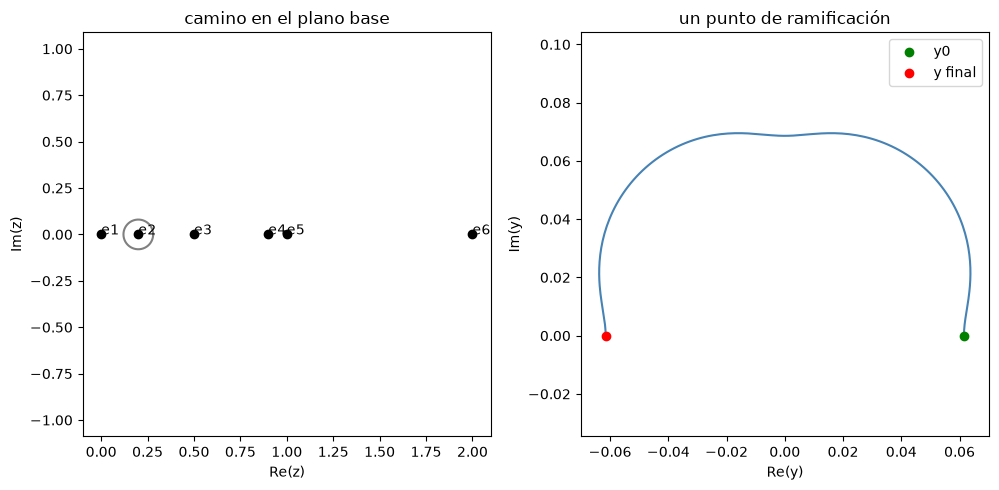

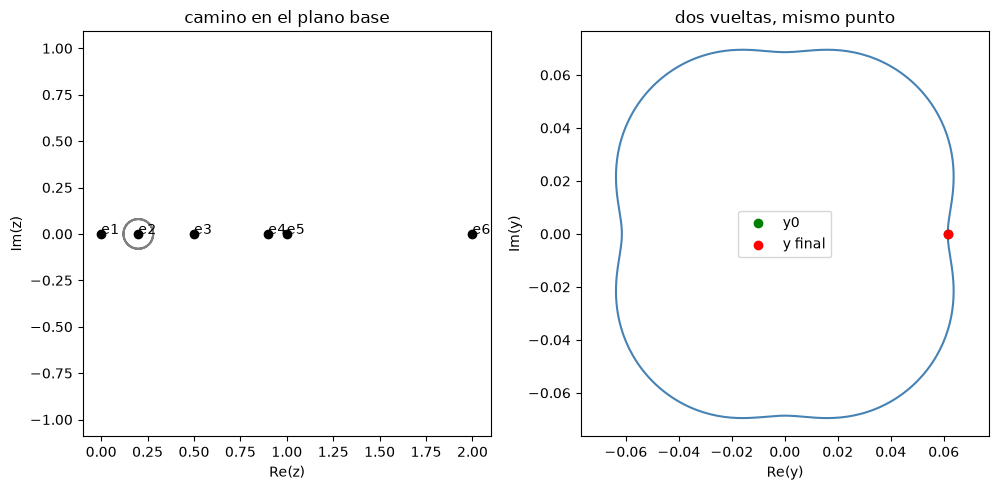

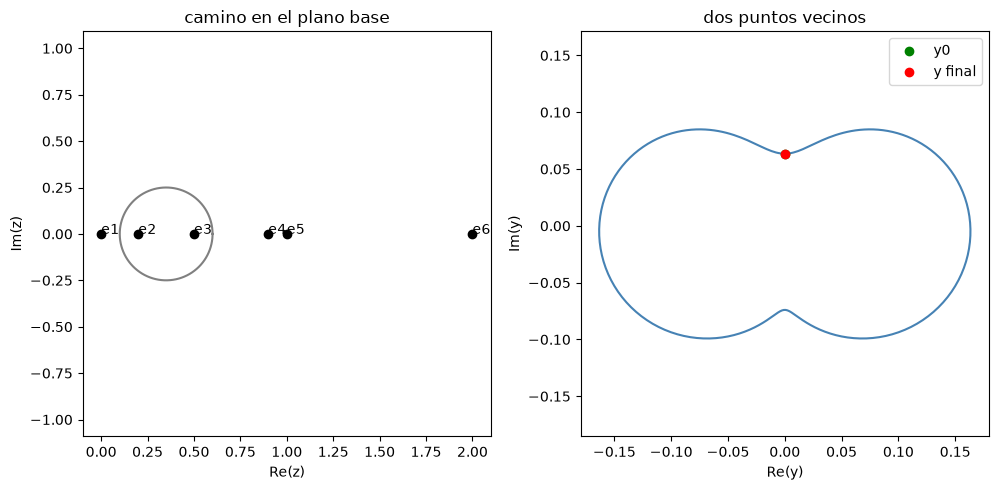

In [96]:
plot_experiment(camino1, y_f, e, "un punto de ramificación")
plot_experiment(camino_2v, y_f_2v, e, "dos vueltas, mismo punto")
plot_experiment(camino3, y_f3, e, "dos puntos vecinos")

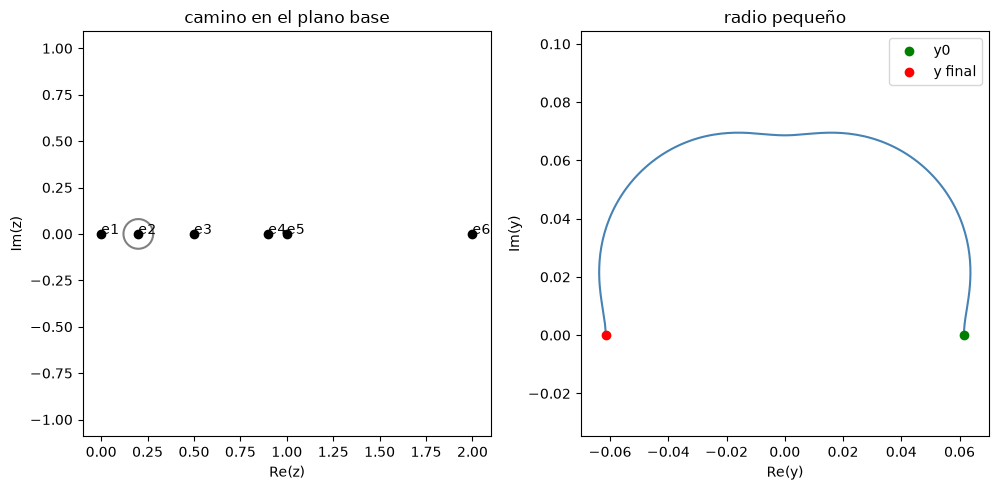

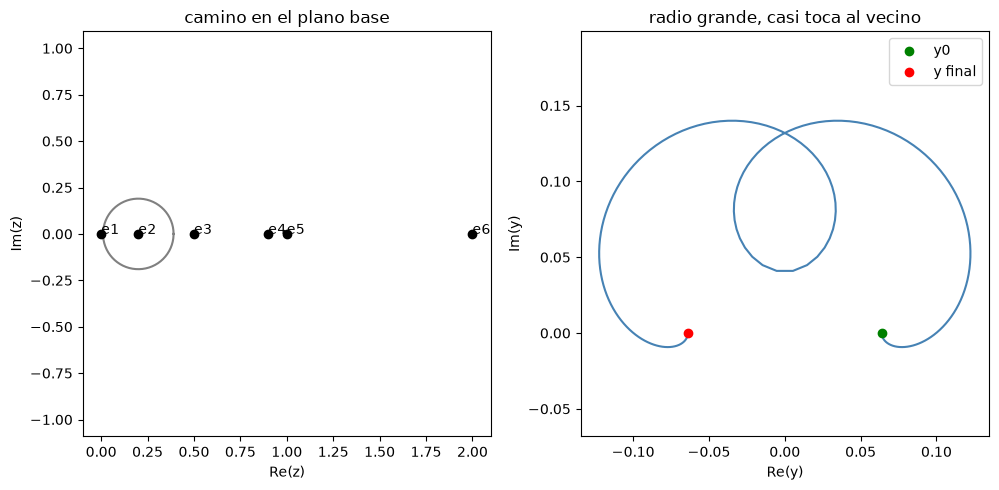

In [102]:
gap_izq = e[index] - e[index-1]
gap_der = e[index+1] - e[index]
radio_max_seguro = min(gap_izq, gap_der)

radio_peque = radio_max_seguro / 2 * 0.8   #el del experimento 1
radio_grande = radio_max_seguro * 0.95     # casi tocando al vecino más cercano

puntos = np.linspace(0, 2*np.pi, 200)

camino_peque = z_path(radio_peque, e[index], puntos)
y_f_peque = continue_sqrt_along_path(camino_peque, e)

camino_grande = z_path(radio_grande, e[index], puntos)
y_f_grande = continue_sqrt_along_path(camino_grande, e)

plot_experiment(camino_peque, y_f_peque, e, "radio pequeño")
plot_experiment(camino_grande, y_f_grande, e, "radio grande, casi toca al vecino")